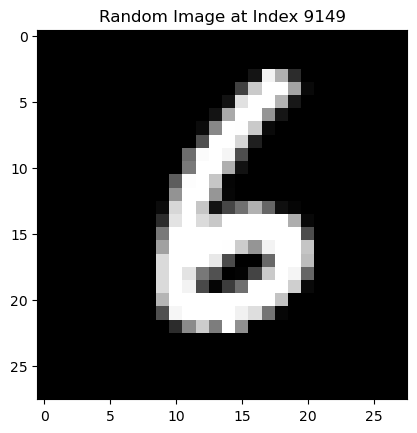

In [6]:
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random

# Load MNIST CSV
file_path = "mnist_test.csv"  # Replace with your actual file path
mnist_data = pd.read_csv(file_path)

# Choose a random row index (skip the first column, which is the label
random_index = np.random.randint(0, len(mnist_data))  # Random index from 0 to len(dataset)-1

# Extract the selected row and reshape it to 28x28
random_image = mnist_data.iloc[random_index, 1:].values.reshape(28, 28).astype(np.uint8)  # Skip label column

# Convert to Pillow Image
img = Image.fromarray(random_image)

# Display the Random Image
plt.imshow(img, cmap="gray")
plt.title(f"Random Image at Index {random_index}")
plt.show()

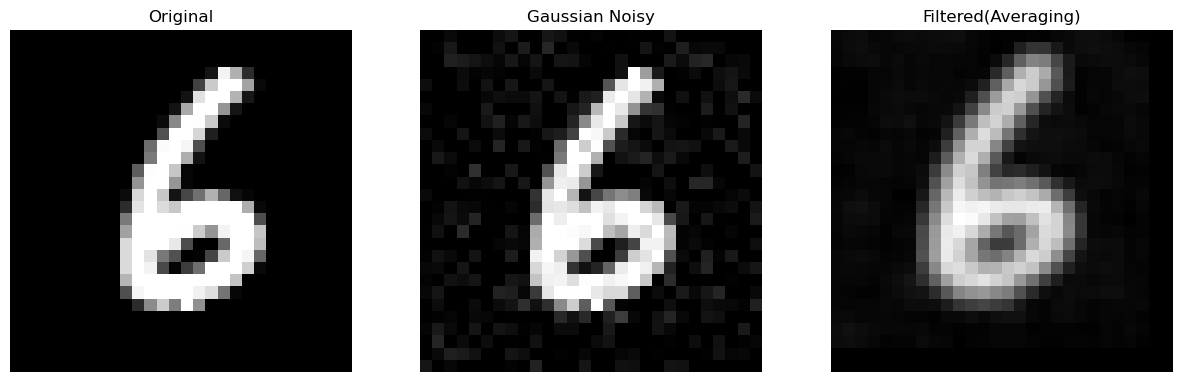

In [7]:
def add_gaussian_noise(image, mean=0, std=20):
    row, col = image.size
    gauss = np.random.normal(mean, std, (col, row))
    noisy = np.array(image) + gauss
    noisy = np.clip(noisy, 0, 255).astype('uint8')
    return Image.fromarray(noisy)

def filtered_image(image, mask):
    row, column = image.shape
    mask_height, mask_width = mask.shape
    filtered_image = np.zeros((row, column))

    # Apply convolution without padding
    for i in range(row - mask_height + 1):
        for j in range(column - mask_width + 1):
            rows = range(i, i + mask_height)
            columns = range(j, j + mask_width)
            part = image[np.ix_(rows, columns)] * mask
            filtered_image[i, j] = part.sum()

    return filtered_image

noisy_image = add_gaussian_noise(img)

averaging_mask = np.ones((3, 3)) / 9.0

noisy_image_np = np.array(noisy_image)
filtered_image_np = filtered_image(noisy_image_np, averaging_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(noisy_image, cmap='gray')
axes[1].set_title('Gaussian Noisy')
axes[1].axis('off')

axes[2].imshow(filtered_image_np, cmap='gray')
axes[2].set_title('Filtered(Averaging)')
axes[2].axis('off')

plt.show()

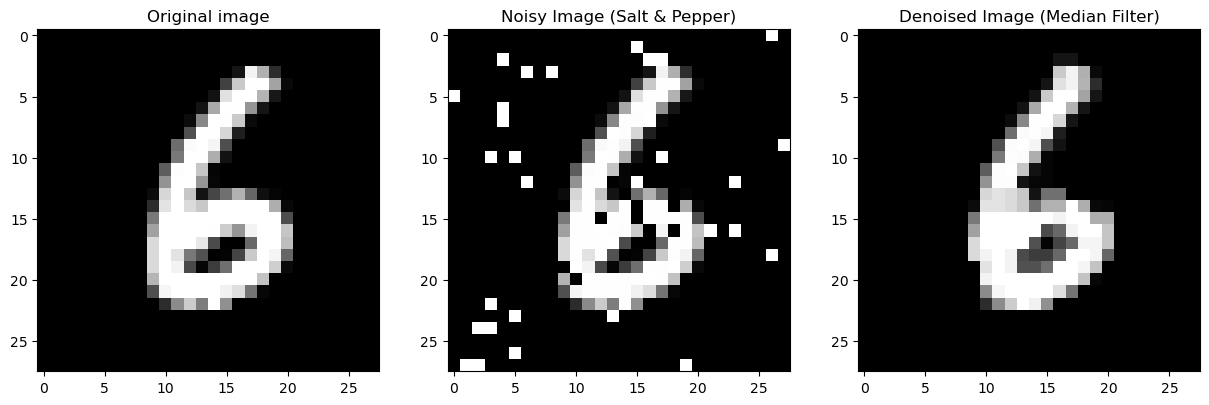

In [8]:
def add_salt_and_pepper_noise(image, prob=0.05):
    noisy_img = np.copy(image)
    total_pixels = image.shape[0] * image.shape[1]
    num_salt = np.ceil(prob * total_pixels)

    # Salt
    for i in range(int(num_salt)):
        y = random.randint(0, image.shape[0] - 1)
        x = random.randint(0, image.shape[1] - 1)
        noisy_img[y, x] = 255

    # Pepper
    for i in range(int(num_salt)):
        y = random.randint(0, image.shape[0] - 1)
        x = random.randint(0, image.shape[1] - 1)
        noisy_img[y, x] = 0

    return noisy_img
    
sp_noisy_image = add_salt_and_pepper_noise(random_image)

def median_filter(image, kernel_size):
  filtered_image = np.zeros_like(image)
  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      neighborhood = image[max(0, i - kernel_size // 2):min(image.shape[0], i + kernel_size // 2 + 1),
                         max(0, j - kernel_size // 2):min(image.shape[1], j + kernel_size // 2 + 1)]
      filtered_image[i, j] = np.median(neighborhood)
  return filtered_image

median_filter = median_filter(sp_noisy_image, 3)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title('Original image')
plt.imshow(random_image, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Noisy Image (Salt & Pepper)')
plt.imshow(sp_noisy_image, cmap='gray')


plt.subplot(1, 3, 3)
plt.title('Denoised Image (Median Filter)')
plt.imshow(median_filter, cmap='gray')

plt.show()